# Task 2 — Student-generated hypotheses (H6–H10)

| ID | Question | Output figures |
|---|---|---|
| **H6** | On consecutive retake pairs: does Δtime relate to Δscore, and do improvers spend time differently? **Two separate graphs:** scatter + LOWESS, then boxplot by improved vs not. | `h6_retake_delta_scatter.png`, `h6_retake_delta_box.png` |
| **H7** | Do students become both higher-scoring and faster across attempts? | `h7_knowledge_efficiency_across_attempts.png` |
| **H8** | Among first-attempt “failers”, do slow starters recover more than fast starters? | `h8_slow_fast_failers_recovery.png` |
| **H9** | Do grades improve from attempt 1 to attempt 2? | `h9_reattempt_improvement.png` |
| **H10** | For students present in multiple quizzes, how consistent are best grades across quiz pairs? | `h10_cross_quiz_consistency.png` |

All figures are written under `outputs/`. Run all cells in order.


## Setup & helpers


In [1]:
from pathlib import Path
import os
# Repo root whether kernel cwd is repo or notebooks/
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
import warnings
warnings.filterwarnings("ignore")
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

QUIZ1_PATH = REPO_ROOT / "data/quiz1/quiz1_marks.csv"
QUIZ2_PATH = REPO_ROOT / "data/quiz2/quiz2_marks.csv"
QUIZ3_PATH = REPO_ROOT / "data/quiz3/quiz3_marks.csv"
OUT_DIR = REPO_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

C1, C2, C3 = "#2E86AB", "#E84855", "#F4A261"
COLORS = [C1, C2, C3]
SUCCESS, BLUE, RED, GREY = "#22C55E", "#2563EB", "#DC2626", "#9CA3AF"
PALETTE = {"primary": BLUE, "neutral": GREY}

def parse_time_to_seconds(text) -> float:
    if pd.isna(text): return np.nan
    s = str(text).strip()
    if s in ("-", ""): return np.nan
    sl, total = s.lower(), 0.0
    for pat, mul in [(r"(\d+)\s*days?", 86400), (r"(\d+)\s*hours?", 3600), (r"(\d+)\s*mins?", 60), (r"(\d+)\s*secs?", 1)]:
        m = re.search(pat, sl)
        if m: total += int(m.group(1)) * mul
    return total if total > 0 else np.nan

def time_sec_to_minutes(time_sec: pd.Series) -> pd.Series:
    s = time_sec.astype(float)
    as_sec, as_ms = s / 60.0, s / 60_000.0
    use_ms = (as_sec > 720.0) & (as_ms <= 720.0) & (as_sec < 10_000.0)
    return pd.Series(np.where(use_ms, as_ms, as_sec), index=time_sec.index, dtype=float)

def attempt_minutes_capped(time_sec_val: float, cap: float = 120.0) -> float:
    if not np.isfinite(time_sec_val) or time_sec_val <= 0:
        return 0.0
    m = float(time_sec_to_minutes(pd.Series([time_sec_val])).iloc[0])
    return float(np.clip(m, 0.0, cap))

def load_quiz(path: Path, quiz_id: int) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df[df["State"] == "Finished"].copy()
    df["grade"] = pd.to_numeric(df["Grade/10.00"], errors="coerce")
    df["time_sec"] = df["Time taken"].apply(parse_time_to_seconds)
    df["time_min"] = time_sec_to_minutes(df["time_sec"])
    q_cols = [c for c in df.columns if c.startswith("Q.")]
    for c in q_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.rename(columns={"Student Code": "student_id"})
    df["quiz"] = quiz_id
    started = df["Started on"].astype(str).str.replace(r"\s+", " ", regex=True)
    df["started_on"] = pd.to_datetime(started, errors="coerce", dayfirst=True, format="mixed")
    df = df.sort_values(["student_id", "started_on"])
    df["attempt_no"] = df.groupby("student_id").cumcount() + 1
    keep = ["student_id", "quiz", "attempt_no", "grade", "time_sec", "time_min", "started_on"] + q_cols
    return df[keep].dropna(subset=["grade", "time_sec"]).reset_index(drop=True)

def triplets(q1, q2, q3):
    return [(q1, "Quiz 1"), (q2, "Quiz 2"), (q3, "Quiz 3")]

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

q1, q2, q3 = load_quiz(QUIZ1_PATH, 1), load_quiz(QUIZ2_PATH, 2), load_quiz(QUIZ3_PATH, 3)
print("Loaded", len(q1), len(q2), len(q3))


Loaded 13911 10430 8066


## H6 — Retake deltas (1/2): Δtime vs Δscore — scatter + LOWESS


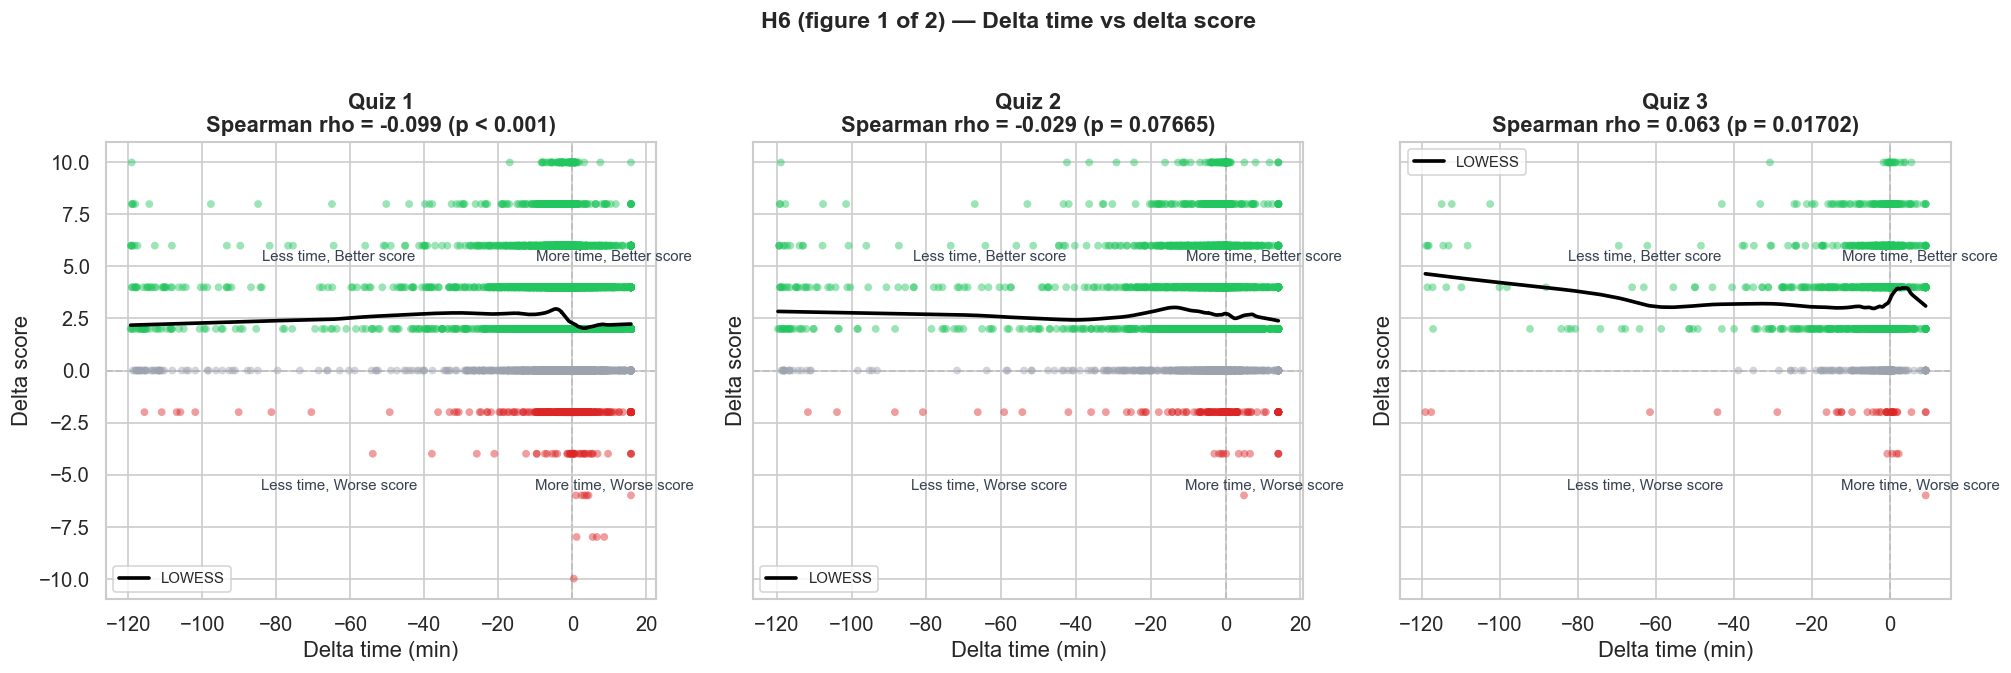

In [2]:
def build_consecutive_pairs(df: pd.DataFrame) -> pd.DataFrame:
    multi = df.groupby("student_id").filter(lambda x: len(x) > 1)
    if multi.empty:
        return pd.DataFrame(columns=["delta_time", "delta_score"])
    multi = multi.dropna(subset=["started_on"])
    rows = []
    for _, grp in multi.groupby("student_id", sort=False):
        grp = grp.sort_values("started_on")
        for i in range(len(grp) - 1):
            t0 = attempt_minutes_capped(float(grp.iloc[i]["time_sec"]))
            t1 = attempt_minutes_capped(float(grp.iloc[i + 1]["time_sec"]))
            g0 = float(grp.iloc[i]["grade"])
            g1 = float(grp.iloc[i + 1]["grade"])
            rows.append({"delta_time": float(t1 - t0), "delta_score": float(g1 - g0)})
    return pd.DataFrame(rows)

prepared = []
for df, label in triplets(q1, q2, q3):
    pairs = build_consecutive_pairs(df)
    if pairs.empty or len(pairs) < 3:
        prepared.append((label, None))
        continue
    cap = pairs["delta_time"].quantile(0.95)
    d = pairs.copy()
    d["delta_time_plot"] = d["delta_time"].clip(upper=cap)
    d["improved"] = np.where(d["delta_score"] > 0, "Improved", "Not improved")
    prepared.append((label, d))

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
for ax, (label, d) in zip(axes, prepared):
    if d is None:
        ax.set_title(f"{label} — insufficient pairs", fontweight="bold")
        continue
    col = np.where(d["delta_score"] > 0, SUCCESS, np.where(d["delta_score"] < 0, RED, GREY))
    ax.scatter(d["delta_time_plot"], d["delta_score"], c=list(col), alpha=0.45, s=22, edgecolors="none")
    ax.axhline(0, color="grey", linestyle="--", linewidth=1.1, zorder=0)
    ax.axvline(0, color="grey", linestyle="--", linewidth=1.1, zorder=0)
    sm = lowess(d["delta_score"], d["delta_time_plot"], frac=0.35)
    ax.plot(sm[:, 0], sm[:, 1], color="black", linewidth=2.2, label="LOWESS", zorder=5)
    ax.legend(loc="best", fontsize=9)
    rho, p_sp = spearmanr(d["delta_time_plot"], d["delta_score"])
    ptxt = "< 0.001" if p_sp < 0.001 else f"= {p_sp:.4g}"
    ax.set_title(f"{label}\nSpearman rho = {rho:.3f} (p {ptxt})", fontweight="bold")
    xl, xr = ax.get_xlim()
    yb, yt = ax.get_ylim()
    ax.set_xlim(min(xl, 0), max(xr, 0))
    ax.set_ylim(min(yb, 0), max(yt, 0))
    xl, xr = ax.get_xlim()
    yb, yt = ax.get_ylim()
    ax.text((0 + xr) / 2, (0 + yt) / 2, "More time, Better score", ha="center", va="center", fontsize=9, color="#374151", zorder=6)
    ax.text((xl + 0) / 2, (0 + yt) / 2, "Less time, Better score", ha="center", va="center", fontsize=9, color="#374151", zorder=6)
    ax.text((0 + xr) / 2, (yb + 0) / 2, "More time, Worse score", ha="center", va="center", fontsize=9, color="#374151", zorder=6)
    ax.text((xl + 0) / 2, (yb + 0) / 2, "Less time, Worse score", ha="center", va="center", fontsize=9, color="#374151", zorder=6)
    ax.set_xlabel("Delta time (min)")
    ax.set_ylabel("Delta score")
fig.suptitle("H6 (figure 1 of 2) — Delta time vs delta score", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / "h6_retake_delta_scatter.png", bbox_inches="tight")
plt.show()


## H6 — Retake deltas (2/2): Δtime by improved vs not — boxplot


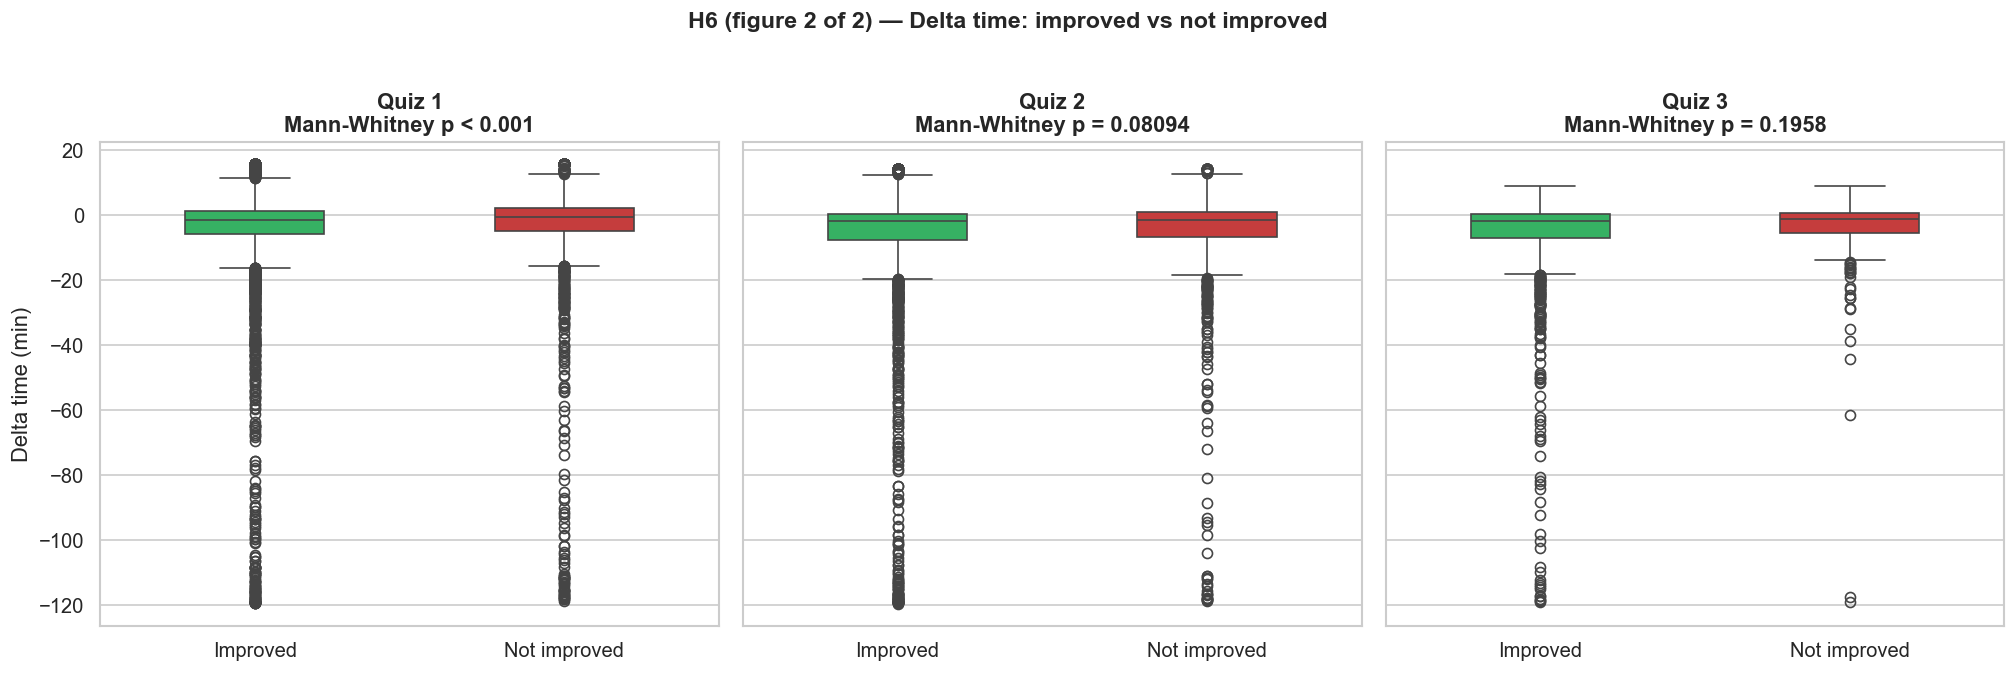

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
for ax, (label, d) in zip(axes, prepared):
    if d is None:
        ax.set_title(f"{label} — insufficient data", fontweight="bold")
        continue
    imp = d.loc[d["improved"] == "Improved", "delta_time_plot"]
    not_imp = d.loc[d["improved"] == "Not improved", "delta_time_plot"]
    if len(imp) >= 1 and len(not_imp) >= 1:
        _, p_mw = mannwhitneyu(imp, not_imp, alternative="two-sided")
        mw_txt = "< 0.001" if p_mw < 0.001 else f"= {p_mw:.4g}"
    else:
        mw_txt = "n/a"
    sns.boxplot(data=d, x="improved", y="delta_time_plot", order=["Improved", "Not improved"], hue="improved", hue_order=["Improved", "Not improved"], palette={"Improved": SUCCESS, "Not improved": RED}, ax=ax, width=0.45, dodge=False, legend=False)
    ax.set_title(f"{label}\nMann-Whitney p {mw_txt}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Delta time (min)")
fig.suptitle("H6 (figure 2 of 2) — Delta time: improved vs not improved", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / "h6_retake_delta_box.png", bbox_inches="tight")
plt.show()


## H7 — Knowledge and efficiency across attempts


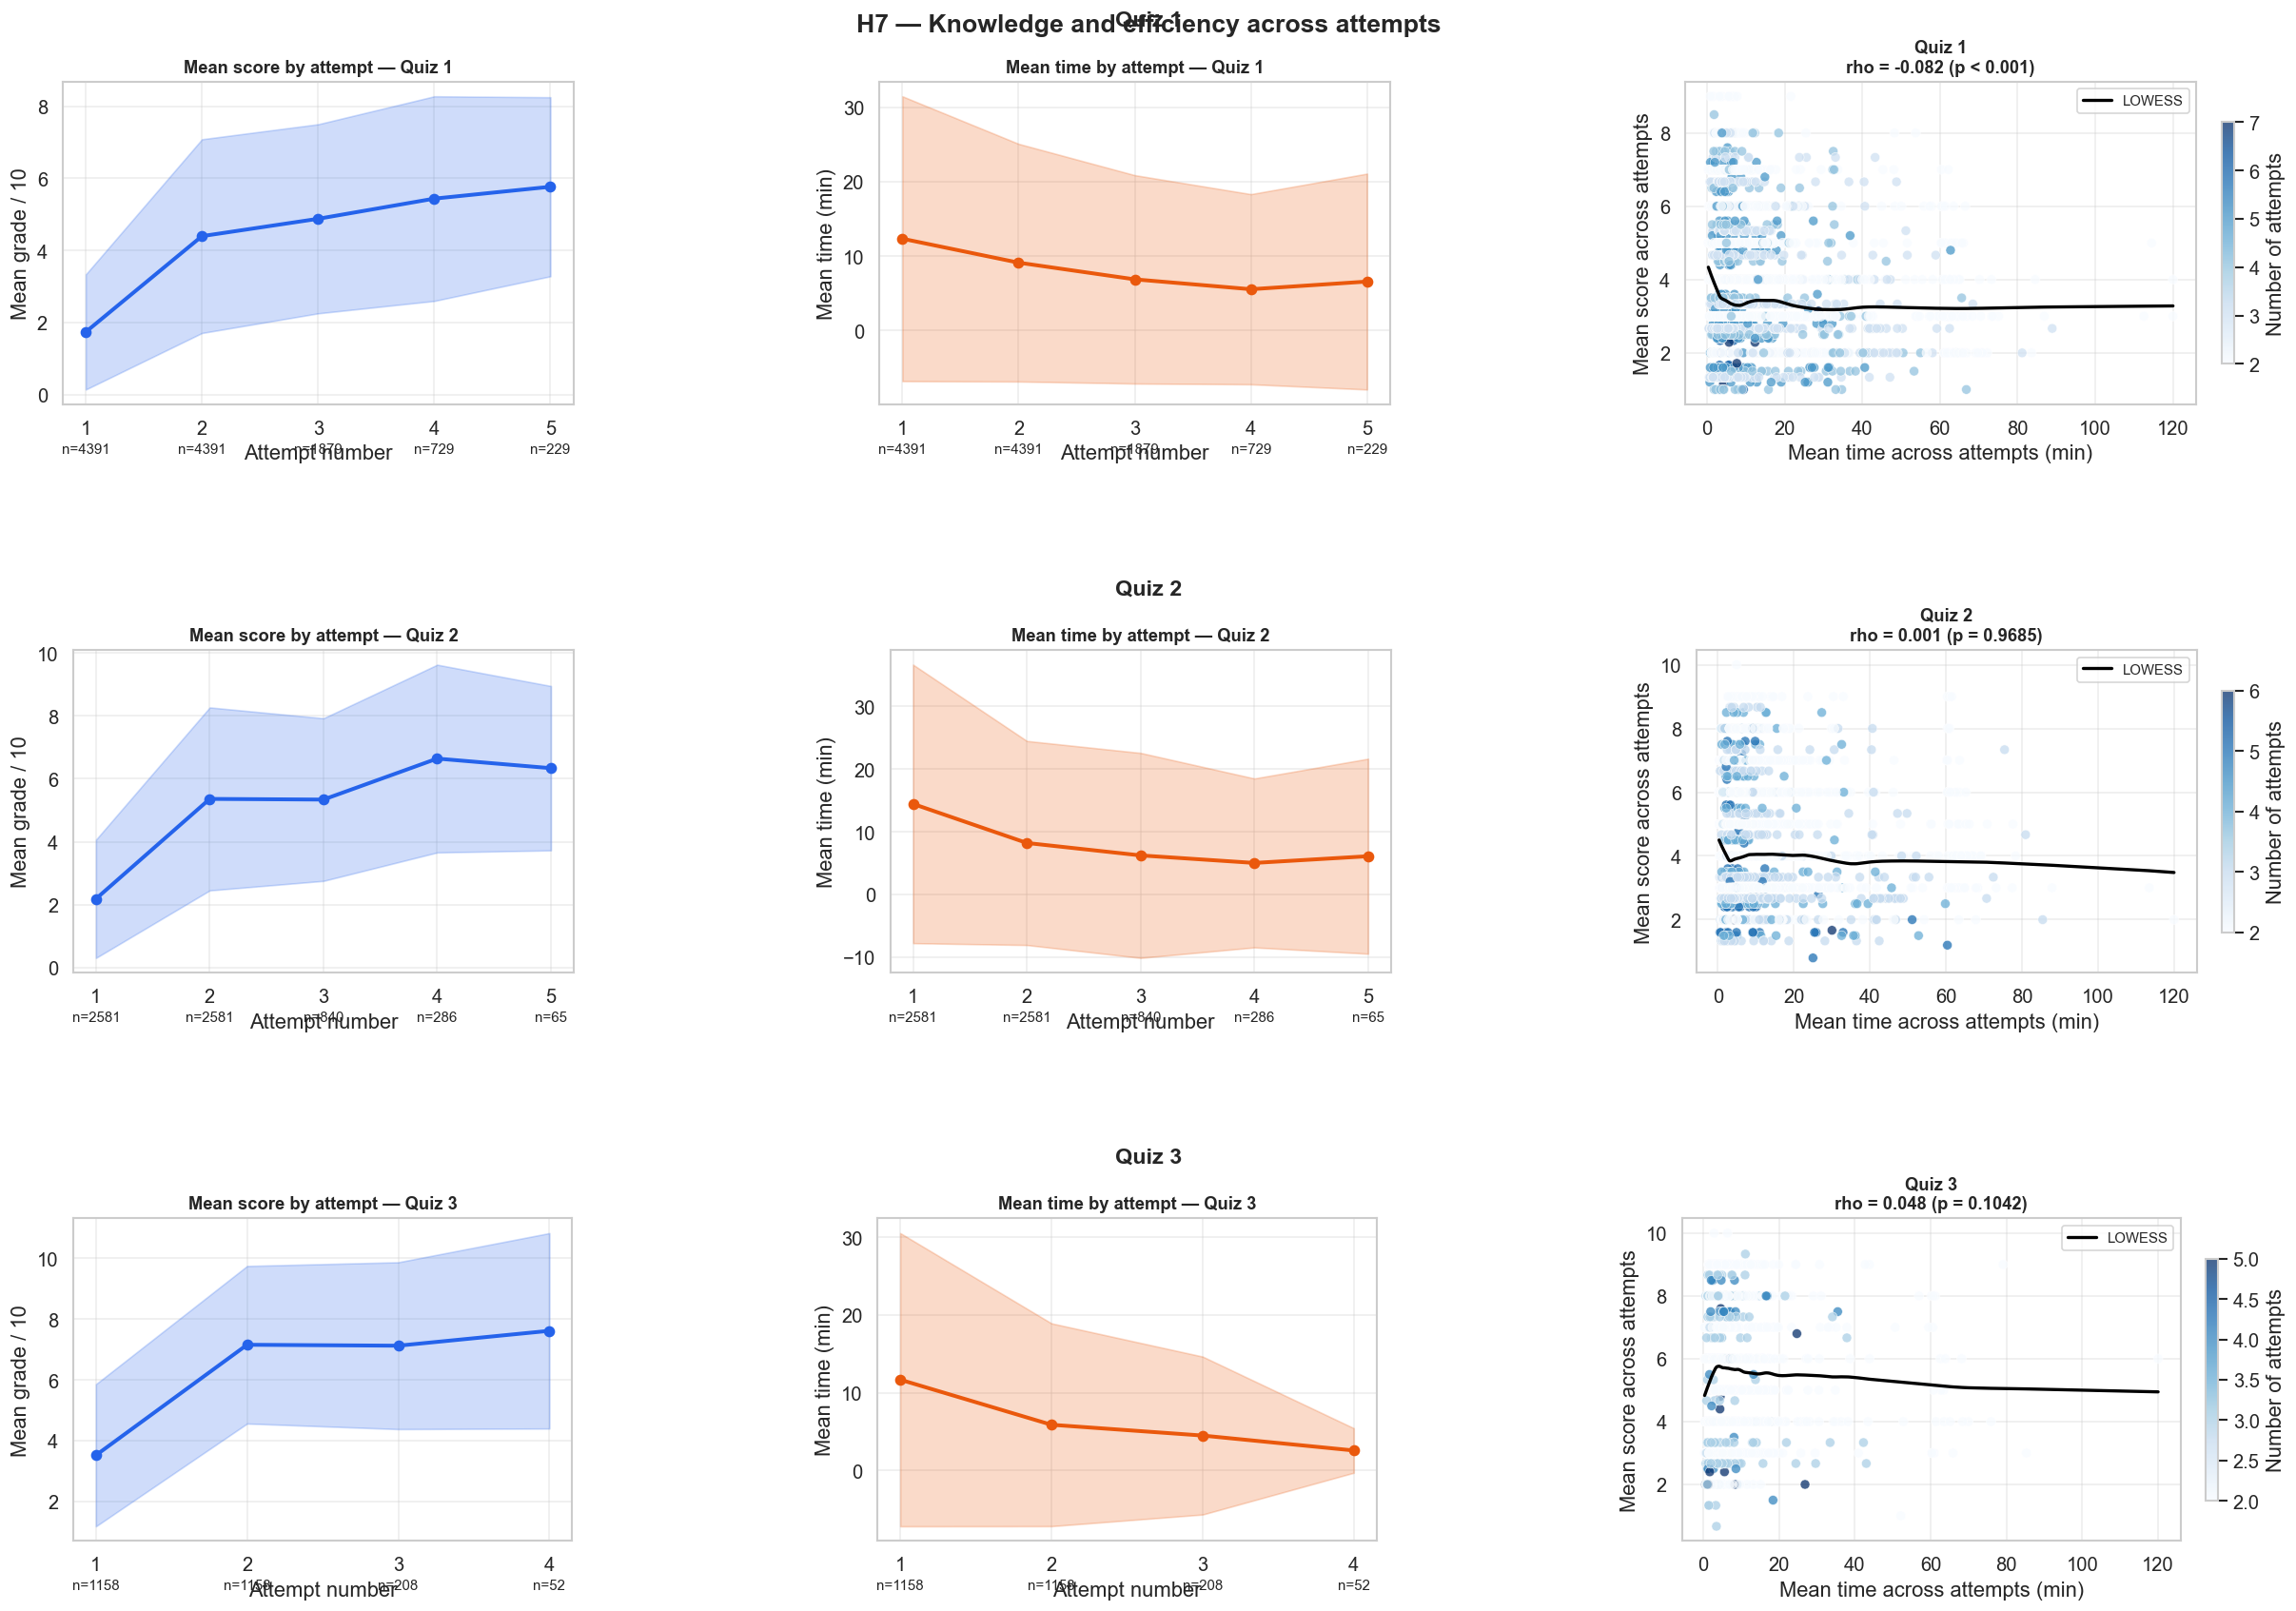

In [4]:
CAP_MIN, MIN_N = 120.0, 30
fig = plt.figure(figsize=(20, 14), layout="constrained")
fig.suptitle("H7 — Knowledge and efficiency across attempts", fontsize=16, fontweight="bold", y=0.995)
subfigs = fig.subfigures(3, 1, hspace=0.2)
for subfig, (df, quiz_label) in zip(subfigs, triplets(q1, q2, q3)):
    subfig.suptitle(quiz_label, fontsize=14, fontweight="bold")
    ax1, ax2, ax3 = subfig.subplots(1, 3, gridspec_kw={"wspace": 0.32})
    multi = df.groupby("student_id").filter(lambda x: len(x) > 1).copy()
    if multi.empty:
        for ax in (ax1, ax2, ax3):
            ax.set_title("No multi-attempt students")
        continue
    multi = multi.sort_values(["student_id", "started_on"])
    multi["att"] = multi.groupby("student_id").cumcount() + 1
    multi["time_capped"] = multi["time_sec"].map(lambda s: attempt_minutes_capped(float(s), CAP_MIN))
    sc = multi.groupby("att")["grade"].agg(["mean", "std", "count"])
    sc = sc[sc["count"] >= MIN_N]
    sc["std"] = sc["std"].fillna(0.0)
    if len(sc) > 0:
        xs = sc.index.to_numpy(dtype=float)
        ax1.plot(xs, sc["mean"], color=BLUE, linewidth=2.4, marker="o", markersize=6)
        ax1.fill_between(xs, sc["mean"] - sc["std"], sc["mean"] + sc["std"], alpha=0.22, color=BLUE)
        ax1.set_xticks(xs)
        for xi, ni in zip(xs, sc["count"]):
            ax1.text(xi, -0.15, f"n={int(ni)}", transform=ax1.get_xaxis_transform(), ha="center", fontsize=9)
    ax1.set_title(f"Mean score by attempt — {quiz_label}", fontweight="bold", fontsize=11)
    ax1.set_xlabel("Attempt number")
    ax1.set_ylabel("Mean grade / 10")
    ax1.grid(True, alpha=0.35)
    tm = multi.groupby("att")["time_capped"].agg(["mean", "std", "count"])
    tm = tm[tm["count"] >= MIN_N]
    tm["std"] = tm["std"].fillna(0.0)
    if len(tm) > 0:
        xt = tm.index.to_numpy(dtype=float)
        ax2.plot(xt, tm["mean"], color="#EA580C", linewidth=2.4, marker="o", markersize=6)
        ax2.fill_between(xt, tm["mean"] - tm["std"], tm["mean"] + tm["std"], alpha=0.22, color="#EA580C")
        ax2.set_xticks(xt)
        for xi, ni in zip(xt, tm["count"]):
            ax2.text(xi, -0.15, f"n={int(ni)}", transform=ax2.get_xaxis_transform(), ha="center", fontsize=9)
    ax2.set_title(f"Mean time by attempt — {quiz_label}", fontweight="bold", fontsize=11)
    ax2.set_xlabel("Attempt number")
    ax2.set_ylabel("Mean time (min)")
    ax2.grid(True, alpha=0.35)
    stu = multi.groupby("student_id").agg(mean_time=("time_capped", "mean"), mean_grade=("grade", "mean"), n_att=("att", "count")).dropna()
    if len(stu) >= 3:
        nmin, nmax = int(stu["n_att"].min()), int(stu["n_att"].max())
        scat = ax3.scatter(stu["mean_time"], stu["mean_grade"], c=stu["n_att"], cmap="Blues", alpha=0.75, s=36, edgecolors="white", linewidths=0.4, vmin=nmin, vmax=nmax)
        subfig.colorbar(scat, ax=ax3, label="Number of attempts", shrink=0.75)
        sm = lowess(stu["mean_grade"], stu["mean_time"], frac=0.45)
        ax3.plot(sm[:, 0], sm[:, 1], color="black", linewidth=2.0, label="LOWESS")
        ax3.legend(loc="best", fontsize=9)
        rho, p_sp = spearmanr(stu["mean_time"], stu["mean_grade"])
        ptxt = "< 0.001" if p_sp < 0.001 else f"= {p_sp:.4g}"
        ax3.set_title(f"{quiz_label}\nrho = {rho:.3f} (p {ptxt})", fontweight="bold", fontsize=11)
    ax3.set_xlabel("Mean time across attempts (min)")
    ax3.set_ylabel("Mean score across attempts")
    ax3.grid(True, alpha=0.35)
fig.savefig(OUT_DIR / "h7_knowledge_efficiency_across_attempts.png", bbox_inches="tight")
plt.show()


## H8 — Slow vs fast failers: recovery


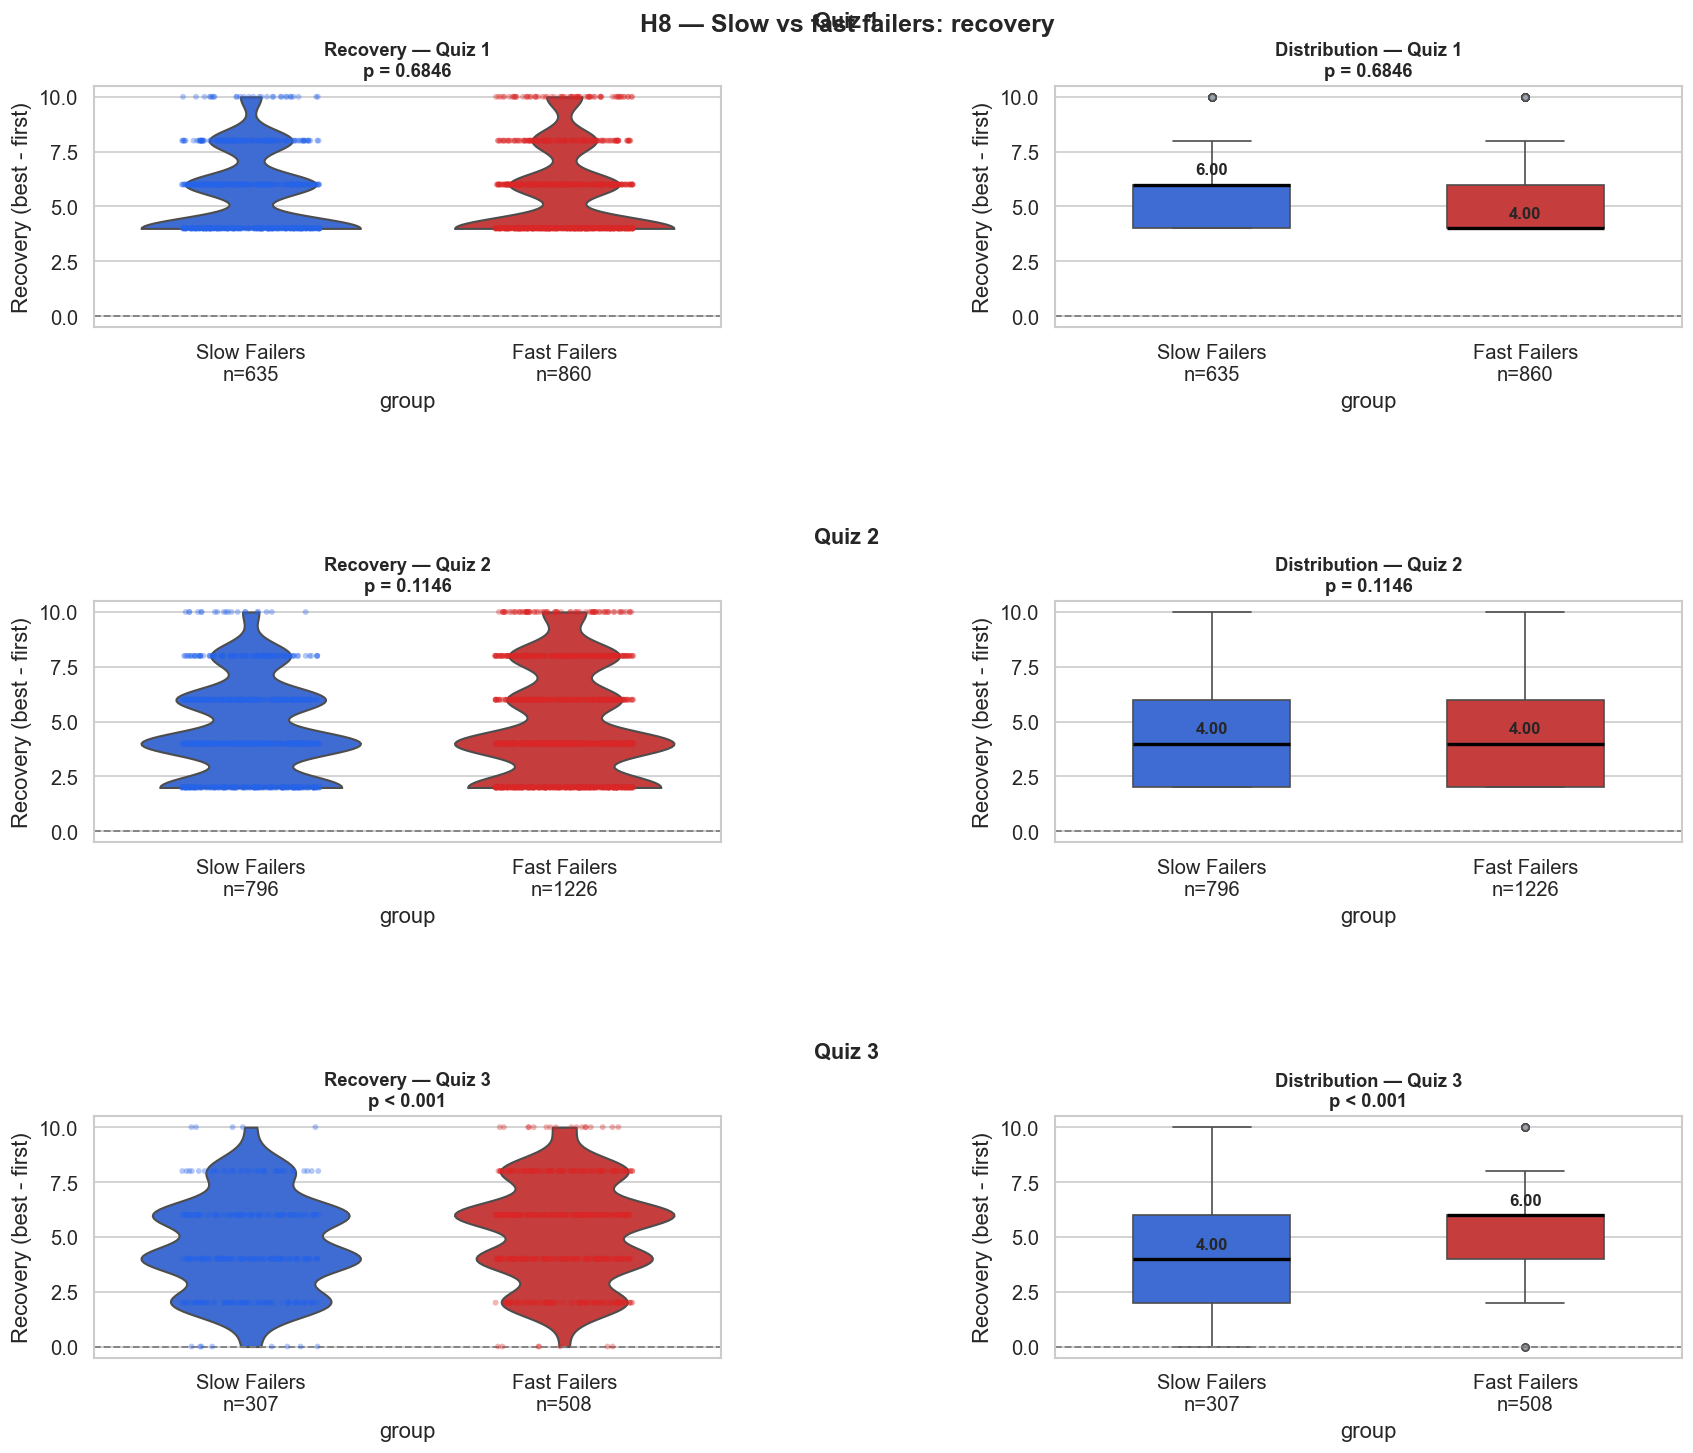

In [5]:
fig = plt.figure(figsize=(14, 12), layout="constrained")
fig.suptitle("H8 — Slow vs fast failers: recovery", fontsize=15, fontweight="bold", y=0.995)
subfigs = fig.subfigures(3, 1, hspace=0.22)
order = ["Slow Failers", "Fast Failers"]
for subfig, (df, quiz_label) in zip(subfigs, triplets(q1, q2, q3)):
    subfig.suptitle(quiz_label, fontsize=13, fontweight="bold")
    ax_v, ax_b = subfig.subplots(1, 2, gridspec_kw={"wspace": 0.3})
    s = df.sort_values(["student_id", "started_on"])
    first = s.groupby("student_id", as_index=False).first()
    first["time_c"] = first["time_sec"].map(lambda x: attempt_minutes_capped(float(x), 120.0))
    med_t, med_g = float(first["time_c"].median()), float(first["grade"].median())
    best = df.groupby("student_id")["grade"].max()
    first_ix = first.set_index("student_id")
    multi_ids = set(df.groupby("student_id").filter(lambda x: len(x) >= 2)["student_id"])
    rows = []
    for sid in multi_ids:
        g0 = float(first_ix.loc[sid, "grade"])
        if g0 >= med_g:
            continue
        tc = float(first_ix.loc[sid, "time_c"])
        grp = "Slow Failers" if tc > med_t else ("Fast Failers" if tc < med_t else None)
        if grp is None:
            continue
        rows.append({"group": grp, "recovery": float(best.loc[sid]) - g0})
    plot_df = pd.DataFrame(rows)
    n_slow = int((plot_df["group"] == "Slow Failers").sum()) if len(plot_df) else 0
    n_fast = int((plot_df["group"] == "Fast Failers").sum()) if len(plot_df) else 0
    if len(plot_df) == 0:
        for ax in (ax_v, ax_b):
            ax.text(0.5, 0.5, "No students in groups", transform=ax.transAxes, ha="center", va="center")
        continue
    slow_s = plot_df.loc[plot_df["group"] == "Slow Failers", "recovery"]
    fast_s = plot_df.loc[plot_df["group"] == "Fast Failers", "recovery"]
    if len(slow_s) >= 1 and len(fast_s) >= 1:
        _, p_mw = mannwhitneyu(slow_s, fast_s, alternative="two-sided")
        ptxt = "< 0.001" if p_mw < 0.001 else f"= {p_mw:.4g}"
    else:
        ptxt = "n/a"
    present = [g for g in order if (plot_df["group"] == g).any()]
    pal_map = {"Slow Failers": BLUE, "Fast Failers": RED}
    xlabels = [f"Slow Failers\nn={n_slow}" if g == "Slow Failers" else f"Fast Failers\nn={n_fast}" for g in present]
    sns.violinplot(data=plot_df, x="group", y="recovery", order=present, hue="group", hue_order=present, palette={g: pal_map[g] for g in present}, ax=ax_v, cut=0, inner=None, width=0.7, dodge=False, legend=False)
    sns.stripplot(data=plot_df, x="group", y="recovery", order=present, hue="group", hue_order=present, palette={g: pal_map[g] for g in present}, ax=ax_v, alpha=0.35, size=3.5, jitter=0.22, dodge=False, legend=False)
    ax_v.axhline(0, color="grey", linestyle="--", linewidth=1.1)
    ax_v.set_xticks(range(len(present)))
    ax_v.set_xticklabels(xlabels)
    ax_v.set_title(f"Recovery — {quiz_label}\np {ptxt}", fontweight="bold", fontsize=11)
    ax_v.set_ylabel("Recovery (best - first)")
    sns.boxplot(data=plot_df, x="group", y="recovery", order=present, hue="group", hue_order=present, palette={g: pal_map[g] for g in present}, ax=ax_b, width=0.5, dodge=False, legend=False, medianprops=dict(color="black", linewidth=2), flierprops=dict(markerfacecolor=GREY, markersize=4, alpha=0.7))
    ax_b.axhline(0, color="grey", linestyle="--", linewidth=1.1)
    ax_b.set_xticks(range(len(present)))
    ax_b.set_xticklabels(xlabels)
    ylo, yhi = ax_b.get_ylim()
    yspan = max(yhi - ylo, 1.0)
    for i, grp in enumerate(present):
        sub = plot_df.loc[plot_df["group"] == grp, "recovery"]
        if len(sub) == 0:
            continue
        ax_b.text(i, float(sub.median()) + 0.03 * yspan, f"{sub.median():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax_b.set_title(f"Distribution — {quiz_label}\np {ptxt}", fontweight="bold", fontsize=11)
    ax_b.set_ylabel("Recovery (best - first)")
fig.savefig(OUT_DIR / "h8_slow_fast_failers_recovery.png", bbox_inches="tight")
plt.show()


## H9 — Attempt 1 to attempt 2 improvement


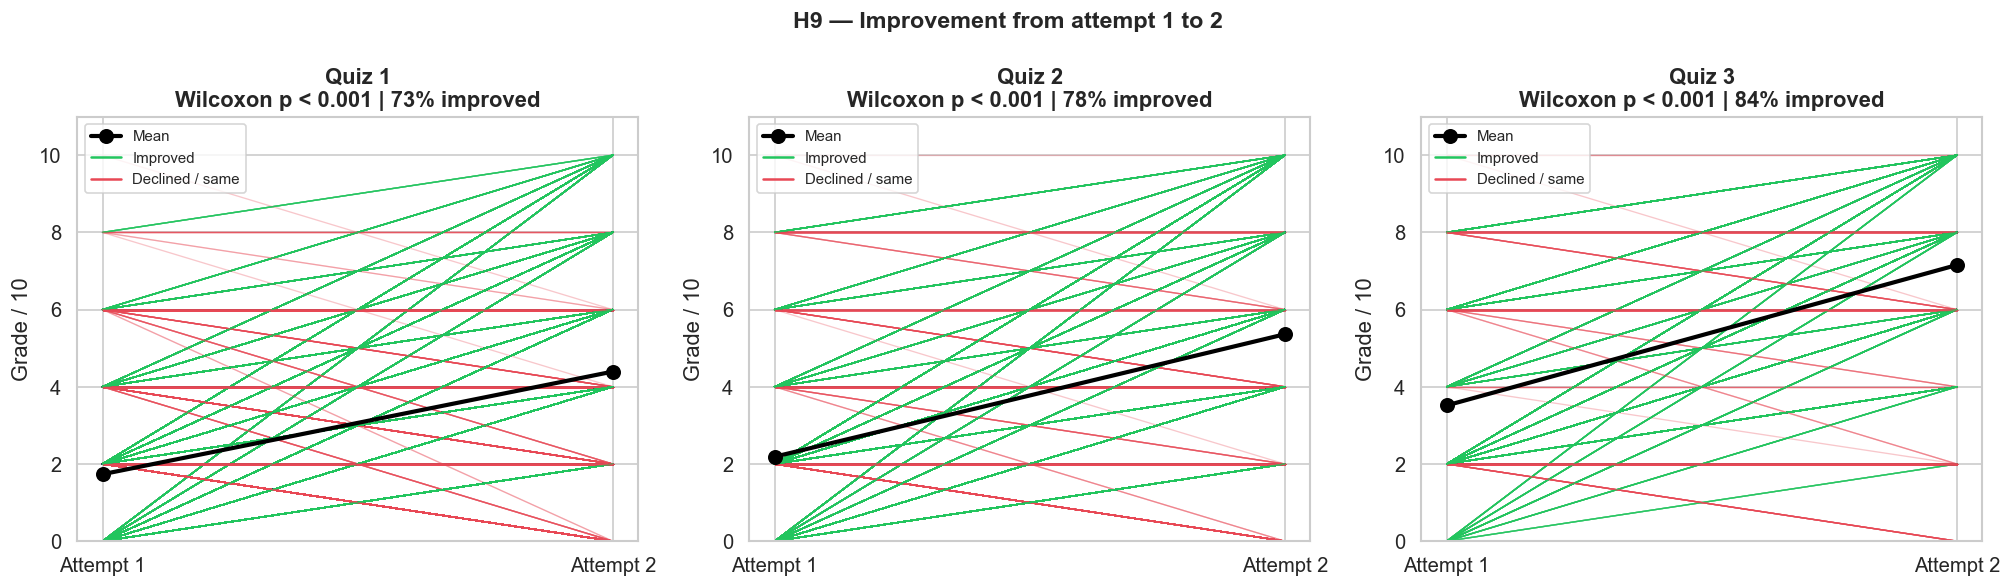

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, label) in zip(axes, triplets(q1, q2, q3)):
    multi = df[df.groupby("student_id")["attempt_no"].transform("max") >= 2]
    pivot = multi[multi["attempt_no"].isin([1, 2])].pivot_table(index="student_id", columns="attempt_no", values="grade").dropna()
    if pivot.shape[1] < 2 or pivot.empty:
        ax.set_title(f"{label} — not enough paired attempts")
        continue
    pivot.columns = ["Attempt 1", "Attempt 2"]
    pivot["improved"] = pivot["Attempt 2"] > pivot["Attempt 1"]
    for _, row in pivot.iterrows():
        c = SUCCESS if row["improved"] else C2
        ax.plot([1, 2], [row["Attempt 1"], row["Attempt 2"]], color=c, alpha=0.3, linewidth=0.8)
    ax.plot([1, 2], [pivot["Attempt 1"].mean(), pivot["Attempt 2"].mean()], color="black", linewidth=2.5, marker="o", markersize=8, label="Mean")
    try:
        _, pval = stats.wilcoxon(pivot["Attempt 1"], pivot["Attempt 2"])
        ptxt = "< 0.001" if pval < 0.001 else f"= {pval:.3f}"
    except ValueError:
        ptxt = "n/a"
    pct = pivot["improved"].mean() * 100
    ax.set_title(f"{label}\nWilcoxon p {ptxt} | {pct:.0f}% improved", fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Attempt 1", "Attempt 2"])
    ax.set_ylabel("Grade / 10")
    ax.set_ylim(0, 11)
    ax.plot([], [], color=SUCCESS, label="Improved")
    ax.plot([], [], color=C2, label="Declined / same")
    ax.legend(fontsize=9)
plt.suptitle("H9 — Improvement from attempt 1 to 2", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "h9_reattempt_improvement.png", bbox_inches="tight")
plt.show()


## H10 — Cross-quiz consistency (best grade overlap)

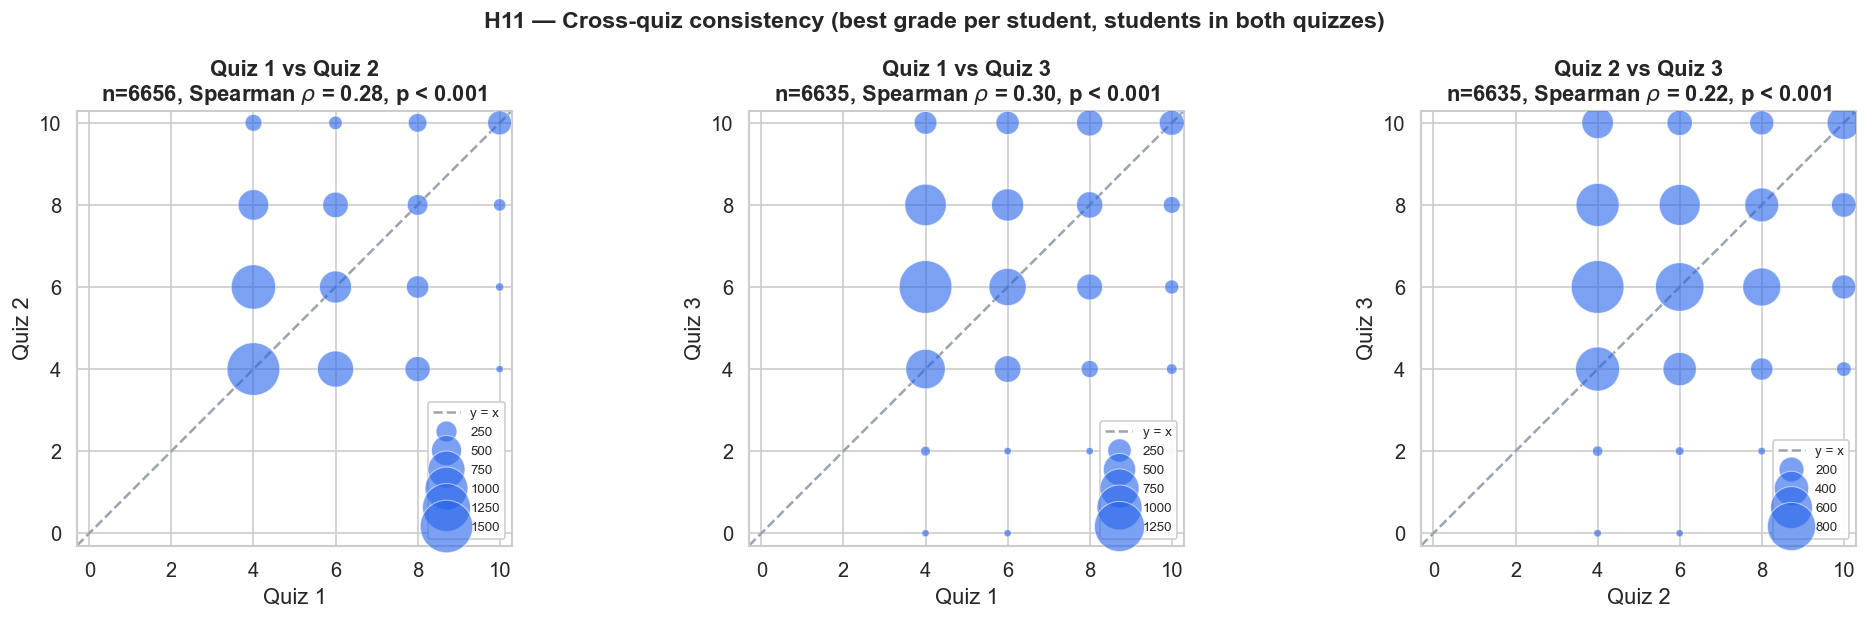

run_h10_cross_quiz_consistency complete → D:\abi\admin\Data-Viz\outputs\h10_cross_quiz_consistency.png


In [7]:
from matplotlib.lines import Line2D


def _best_grade(df: pd.DataFrame) -> pd.Series:
    return df.groupby("student_id")["grade"].max()


def run_h10_cross_quiz_consistency(
    q1: pd.DataFrame,
    q2: pd.DataFrame,
    q3: pd.DataFrame,
    out_dir: Path,
    show: bool = True,
) -> None:
    s1 = _best_grade(q1).rename("Quiz 1")
    s2 = _best_grade(q2).rename("Quiz 2")
    s3 = _best_grade(q3).rename("Quiz 3")
    wide = pd.concat([s1, s2, s3], axis=1)

    pair_cols = [("Quiz 1", "Quiz 2"), ("Quiz 1", "Quiz 3"), ("Quiz 2", "Quiz 3")]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
    lims = (-0.3, 10.3)

    for ax, (c1, c2) in zip(axes, pair_cols):
        raw = wide[[c1, c2]].dropna()
        n = len(raw)
        if n < 3:
            ax.set_title(f"{c1} vs {c2} — insufficient overlap", fontweight="bold")
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            continue

        ax.plot(
            [lims[0], lims[1]],
            [lims[0], lims[1]],
            linestyle="--",
            color=PALETTE["neutral"],
            linewidth=1.5,
            zorder=1,
        )

        counts = raw.groupby([c1, c2], observed=True).size().reset_index(name="n_students")

        sns.scatterplot(
            data=counts,
            x=c1,
            y=c2,
            size="n_students",
            sizes=(20, 1000),
            color=PALETTE["primary"],
            alpha=0.6,
            edgecolor="white",
            linewidth=0.6,
            zorder=3,
            ax=ax,
            legend=True,
        )

        rho, pval = spearmanr(raw[c1], raw[c2])
        ppart = "< 0.001" if pval < 0.001 else f"= {pval:.3f}"
        ax.set_title(
            f"{c1} vs {c2}\nn={n}, Spearman $\\rho$ = {rho:.2f}, p {ppart}",
            fontweight="bold",
        )

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(lims)
        ax.set_ylim(lims)

        leg = ax.get_legend()
        ident = Line2D(
            [0],
            [0],
            color=PALETTE["neutral"],
            linestyle="--",
            linewidth=1.5,
            label="y = x",
        )
        new_handles = [ident]
        new_labels = ["y = x"]
        if leg is not None:
            hs = list(leg.legend_handles)
            labs = [t.get_text() for t in leg.texts]
            if len(labs) == len(hs) + 1:
                labs = labs[1:]
            elif len(labs) > len(hs):
                labs = labs[-len(hs) :]
            for h, lb in zip(hs, labs[: len(hs)]):
                new_handles.append(h)
                new_labels.append(lb)
            leg.remove()
        ax.legend(new_handles, new_labels, loc="lower right", fontsize=8, framealpha=0.95)

    fig.suptitle(
        "H11 — Cross-quiz consistency (best grade per student, students in both quizzes)",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    out_path = out_dir / "h10_cross_quiz_consistency.png"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    print(f"run_h10_cross_quiz_consistency complete → {out_path}")


run_h10_cross_quiz_consistency(q1, q2, q3, OUT_DIR)